0      759.400
1      882.733
2     1155.330
3     1565.270
4     2766.800
5    10837.600
Name: throughput_txn_per_sec, dtype: float64
0      438.133
1      809.267
2     1056.870
3     1483.070
4     2687.130
5    10606.800
Name: throughput_txn_per_sec, dtype: float64


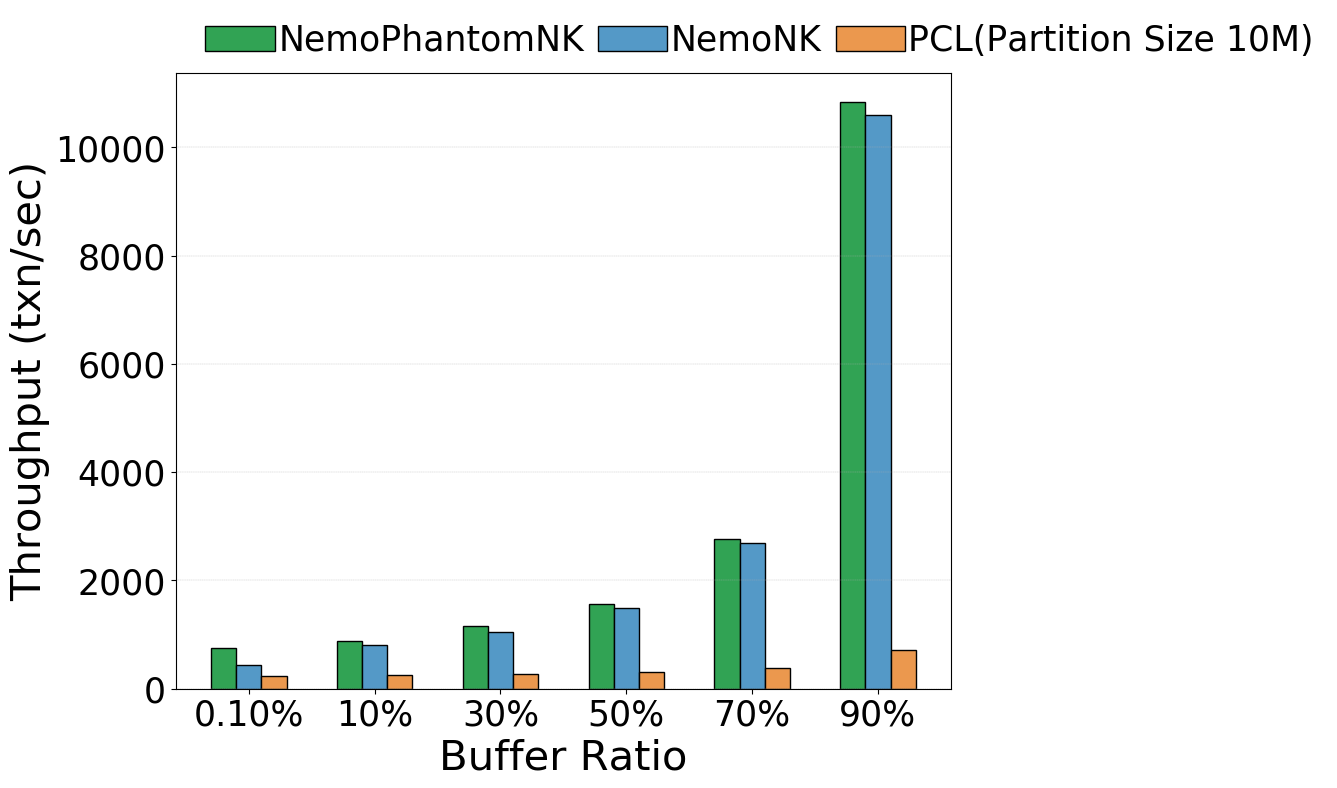

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25
x_dimension = "g_total_buf_sz"
color_indices, line_colors = select_color_idx(4)
nemo_batch_evict_c = "#31a354"
nemo_record_evict_c = line_colors["BLUE"] 
pcl_c = line_colors["ORANGE"]

# line_colors = {
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
nemo_batch_evict_label = "NemoPhantomNK"
nemo_record_evict_label = "NemoNK"
pcl_label = "PCL(Partition Size 10M)"

# datadir = "../../output/"
# exp_tuple_batch_evict = "exp_phantom_100m_varybuf_phantomnext_mixquery_nolog"
# exp_tuple_record_evict = "exp_phantom_100m_varybuf_nextkey_mixquery_nolog"
# exp_pcl = "exp_phantom_100m_varybuf_pcl_mixquery_nolog"

datadir = "../../output/phantom_protection/"
exp_tuple_batch_evict = "pp_uni_varybuf_phantomnext-recordsz1024-read0-negative1"
exp_tuple_record_evict = "pp_uni_varybuf_nextkey-recordsz1024-read0-negative1"
exp_pcl = "pp_uni_varybuf_pcl-recordsz1024-read0-negative1"

# Load and prepare the data

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
# data_tuple_batch = [item for item in data_tuple_batch if item["zipf_theta_"] == 0]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by=x_dimension)
# print(df_tuple_batch)

# data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_tuple_record_evict + ".txt")]
# data_tuple_record = [item for item in data_tuple_record if item["zipf_theta_"] == 0]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by=x_dimension)

data_pcl = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_pcl + ".txt")]
df_pcl = pd.DataFrame().from_records(data_pcl).sort_values(by=x_dimension)


fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.2
indices = np.arange(len(df_tuple_batch))
offset = bar_width

# Bar chart for the primary data
batch_bars = ax1.bar(indices - offset , df_tuple_batch["throughput_txn_per_sec"], bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c,edgecolor='black')
record_bars = ax1.bar(indices, df_tuple_record["throughput_txn_per_sec"], bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c,edgecolor='black')
pcl_bars = ax1.bar(indices + offset, df_pcl["throughput_txn_per_sec"], bar_width, label=pcl_label, color=pcl_c,edgecolor='black')
print(df_tuple_batch["throughput_txn_per_sec"])
print( df_tuple_record["throughput_txn_per_sec"])
# speedup = ((df_tuple_batch["throughput_txn_per_sec"] / 
#            df_tuple_record["throughput_txn_per_sec"] ) )

# for idx, (bar, gain) in enumerate(zip(batch_bars, speedup)):
#     height = bar.get_height()
#     ax1.text(bar.get_x() + bar.get_width()/2, height,
#             f'{gain:.2f}x',
#             ha='center', va='bottom',
#             fontsize=ticksize-5)

ax1.set_xticks(indices)
# ax1.set_xticklabels(df_tuple_batch[x_dimension]*1.0/(df_tuple_batch["g_record_size"] * df_tuple_batch["domain_size_"]), fontsize=ticksize)


vals = df_tuple_batch[x_dimension] / (
        df_tuple_batch['g_record_size'] * df_tuple_batch['domain_size_'])

labels = [f'{v*100:.2f}%' if v < 0.01 else f'{v*100:.0f}%'
          for v in vals]

# (You should have called ax1.set_xticks(vals) earlier, or the
#  ticks won’t line up with these labels.)

ax1.set_xticklabels(labels, fontsize=ticksize)

# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_ylim(0, 800)


ax1.set_ylabel("Throughput (txn/sec)", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
# ax1.set_xlabel("Record Size (100K rows, cache size = data size, Read-only, Uniform Dist)", fontsize=ticksize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)
# ax1.title.set_text("Throughput Comparison")
legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')




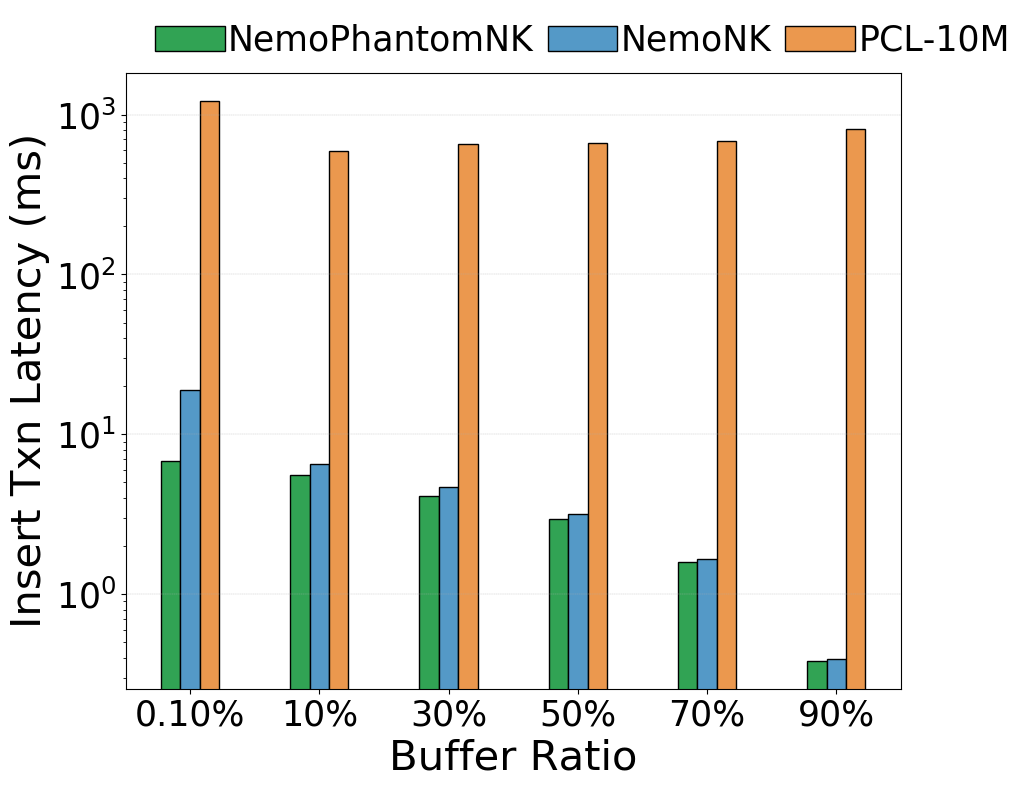

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25
# x_dimension = "g_total_buf_sz"
# color_indices, line_colors = select_color_idx(4)
# nemo_batch_evict_c = "#31a354"
# nemo_record_evict_c =  "#ea801c"

# x_dimension = "zipf_theta_"
x_dimension = "g_total_buf_sz"
color_indices, line_colors = select_color_idx(4)
nemo_batch_evict_c = "#31a354"
nemo_record_evict_c = line_colors["BLUE"] 
pcl_c = line_colors["ORANGE"]
# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
# nemo_batch_evict_label = "NemoNKPhantomEntry"
# nemo_record_evict_label = "NemoNK"

# datadir = "../../output/"
# exp_tuple_batch_evict = "exp_phantom_100m_varybuf_phantomnext_mixquery_nolog"
# exp_tuple_record_evict = "exp_phantom_100m_varybuf_nextkey_mixquery_nolog"


nemo_batch_evict_label = "NemoPhantomNK"
nemo_record_evict_label = "NemoNK"
pcl_label = "PCL-10M"

datadir = "../../output/phantom_protection/"
exp_tuple_batch_evict = "pp_uni_varybuf_phantomnext-recordsz1024-read0-negative1"
exp_tuple_record_evict = "pp_uni_varybuf_nextkey-recordsz1024-read0-negative1"
exp_pcl = "pp_uni_varybuf_pcl-recordsz1024-read0-negative1"
# exp_tuple_batch_evict = "pp_varyskew_phantomnext-recordsz1024-read0-negative1"
# exp_tuple_record_evict = "pp_varyskew_nextkey-recordsz1024-read0-negative1"
# exp_pcl = "pp_varyskew_pcl_10m-recordsz1024-read0-negative1"

# Load and prepare the data

data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
# data_tuple_batch = [item for item in data_tuple_batch if item["zipf_theta_"] == 0]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by=x_dimension)
# print(df_tuple_batch)

# data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_tuple_record_evict + ".txt")]
# data_tuple_record = [item for item in data_tuple_record if item["zipf_theta_"] == 0]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by=x_dimension)

data_pcl = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_pcl + ".txt")]
df_pcl = pd.DataFrame().from_records(data_pcl).sort_values(by=x_dimension)


fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(df_tuple_batch))
offset = bar_width

# avg_sum_insert_txn_latency (us)
# insert_txn_latency_avg_us
measure =  "avg_sum_insert_txn_latency (us)"

# Bar chart for the primary data
batch_bars = ax1.bar(indices - offset , df_tuple_batch[measure]*1.0/1000, bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c,edgecolor='black')
record_bars = ax1.bar(indices, df_tuple_record[measure]*1.0/1000, bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c,edgecolor='black')
pcl_bars = ax1.bar(indices + offset, df_pcl[measure]*1.0/1000, bar_width, label=pcl_label, color=pcl_c,edgecolor='black')


# speedup = ((df_tuple_record[measure]/ df_tuple_batch[measure]) )

# for idx, (bar, gain) in enumerate(zip(record_bars, speedup)):
#     height = bar.get_height()
#     ax1.text(bar.get_x() + bar.get_width()/2, height,
#             f'{gain:.2f}x',
#             ha='center', va='bottom',
#             fontsize=ticksize-5)
ax1.set_xticks(indices)
# ax1.set_xticklabels(df_tuple_batch[x_dimension]*1.0/(df_tuple_batch["g_record_size"] * df_tuple_batch["domain_size_"]), fontsize=ticksize)

# vals = df_tuple_batch[x_dimension] 

# labels = [f'{0:.2f}' if v < 0.00001 else f'{v:.2f}'
#           for v in vals]


vals = df_tuple_batch[x_dimension] / (
        df_tuple_batch['g_record_size'] * df_tuple_batch['domain_size_'])

labels = [f'{v*100:.2f}%' if v < 0.01 else f'{v*100:.0f}%'
          for v in vals]

# (You should have called ax1.set_xticks(vals) earlier, or the
#  ticks won’t line up with these labels.)

ax1.set_xticklabels(labels, fontsize=ticksize)

# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
ax1.set_yscale('log')
# ax1.set_ylim(0, 1500)


ax1.set_ylabel("Insert Txn Latency (ms)", fontsize=txtsize)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
# ax1.set_xlabel("Record Size (100K rows, cache size = data size, Read-only, Uniform Dist)", fontsize=ticksize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)
# ax1.title.set_text("Throughput Comparison")
legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')




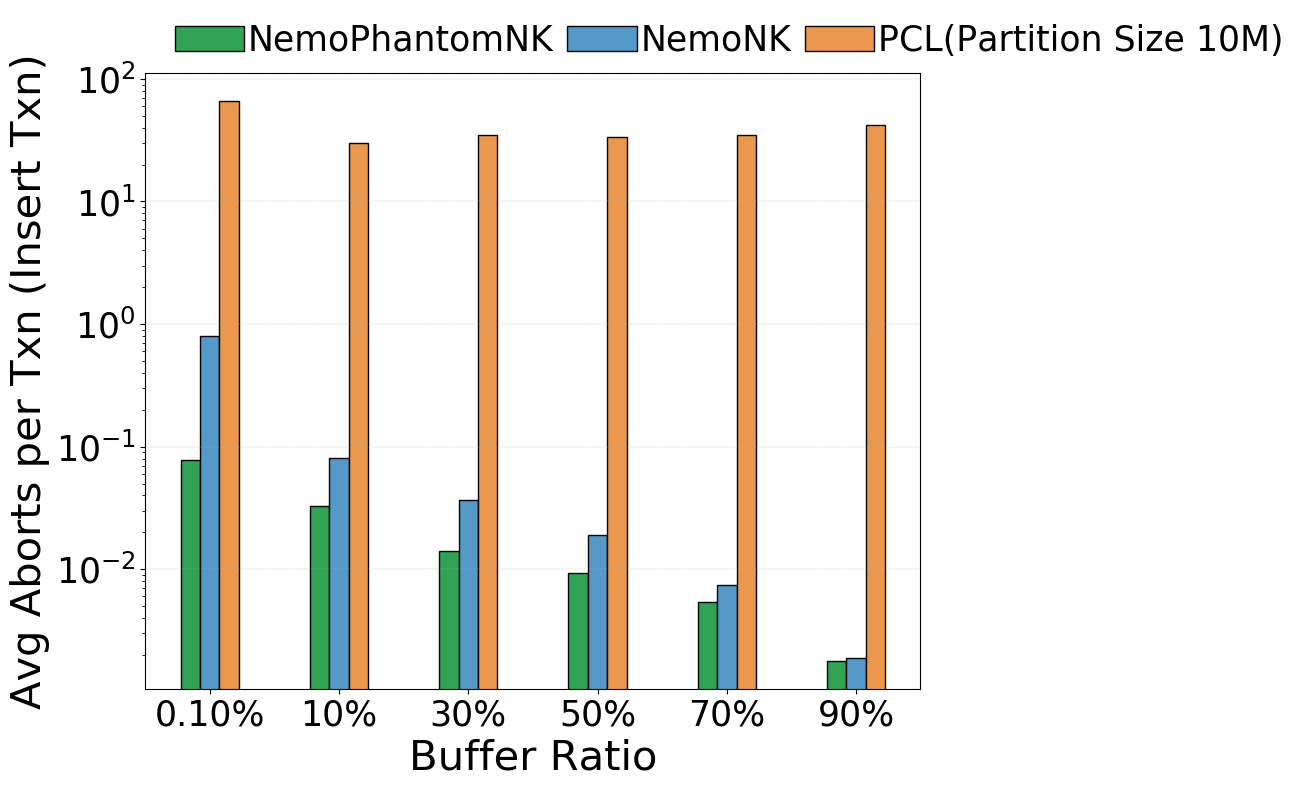

In [6]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25
x_dimension = "g_total_buf_sz"
color_indices, line_colors = select_color_idx(4)

nemo_batch_evict_c = "#31a354"
nemo_record_evict_c = line_colors["BLUE"] 
pcl_c = line_colors["ORANGE"]

# # page_retain_c = line_colors["BLUE"]
# page_evict_c = "#78c679"
# tt_retain_c = "#1f6f6f"
# tt_evict_c = "#54a1a1"

# nemo_batch_evict_label = "Nemo-BatchEvict"
# nemo_record_evict_label = "Nemo-RecordEvict"
# nemo_batch_evict_label = "NemoNKPhantomEntry"
# nemo_record_evict_label = "NemoNK"

nemo_batch_evict_label = "NemoPhantomNK"
nemo_record_evict_label = "NemoNK"
pcl_label = "PCL(Partition Size 10M)"




datadir = "../../output/phantom_protection/"
exp_tuple_batch_evict = "pp_uni_varybuf_phantomnext-recordsz1024-read0-negative1"
exp_tuple_record_evict = "pp_uni_varybuf_nextkey-recordsz1024-read0-negative1"
exp_pcl = "pp_uni_varybuf_pcl-recordsz1024-read0-negative1"


data_tuple_batch = [json.loads(line) for line in open(datadir + exp_tuple_batch_evict + ".txt")]
# data_tuple_batch = [item for item in data_tuple_batch if item["zipf_theta_"] == 0]
df_tuple_batch = pd.DataFrame().from_records(data_tuple_batch).sort_values(by=x_dimension)
# print(df_tuple_batch)

# data_tuple_record = [json.loads(line) for line in open(datadir + exp_tuple_record_evict + ".txt")]
data_tuple_record = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_tuple_record_evict + ".txt")]
# data_tuple_record = [item for item in data_tuple_record if item["zipf_theta_"] == 0]
df_tuple_record = pd.DataFrame().from_records(data_tuple_record).sort_values(by=x_dimension)



data_pcl = [json.loads(line.replace("inf", "0")) for line in open(datadir + exp_pcl + ".txt")]
df_pcl = pd.DataFrame().from_records(data_pcl).sort_values(by=x_dimension)




fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(df_tuple_batch))
offset = bar_width

# avg_sum_insert_txn_latency (us)
# insert_txn_latency_avg_us

# Bar chart for the primary data
batch_bars = ax1.bar(indices - offset , df_tuple_batch["rw_abort_cnt_"]/df_tuple_batch["insert_commit_cnt_"], bar_width, label=nemo_batch_evict_label, color=nemo_batch_evict_c,edgecolor='black')
record_bars = ax1.bar(indices, df_tuple_record["rw_abort_cnt_"]/ df_tuple_record["insert_commit_cnt_"], bar_width, label=nemo_record_evict_label, color=nemo_record_evict_c,edgecolor='black')
pcl_bars = ax1.bar(indices + offset, df_pcl["rw_abort_cnt_"]/ df_pcl["insert_commit_cnt_"], bar_width, label=pcl_label, color=pcl_c,edgecolor='black')


# speedup = ((( df_tuple_record["rw_abort_cnt_"]/ df_tuple_record["insert_commit_cnt_"])/ (df_tuple_batch["rw_abort_cnt_"]/df_tuple_batch["insert_commit_cnt_"])) )

# for idx, (bar, gain) in enumerate(zip(record_bars, speedup)):
#     height = bar.get_height()
#     ax1.text(bar.get_x() + bar.get_width()/2, height,
#             f'{gain:.2f}x',
#             ha='center', va='bottom',
#             fontsize=ticksize-5)
ax1.set_xticks(indices)
# ax1.set_xticklabels(df_tuple_batch[x_dimension]*1.0/(df_tuple_batch["g_record_size"] * df_tuple_batch["domain_size_"]), fontsize=ticksize)


vals = df_tuple_batch[x_dimension] / (
        df_tuple_batch['g_record_size'] * df_tuple_batch['domain_size_'])

labels = [f'{v*100:.2f}%' if v < 0.01 else f'{v*100:.0f}%'
          for v in vals]

# (You should have called ax1.set_xticks(vals) earlier, or the
#  ticks won’t line up with these labels.)

ax1.set_xticklabels(labels, fontsize=ticksize)

# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
ax1.set_yscale('log')
# ax1.set_ylim(0, 150)


ax1.set_ylabel("Avg Aborts per Txn (Insert Txn)", fontsize=txtsize)
# ax1.set_xlabel("Buffer Ratio (10GB, Write-heavy, Uniform Dist)", fontsize=txtsize)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
# ax1.set_xlabel("Record Size (100K rows, cache size = data size, Read-only, Uniform Dist)", fontsize=ticksize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)
# ax1.title.set_text("Throughput Comparison")
legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(0.02, 1, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Legend
# ax1.legend(loc='upper left')

# plt.savefig("/home/hippo/Bonsai-private/paper/experiment/debug_eviction.pdf", bbox_inches='tight')


